# SDPD Racial Disparity Analysis
## Machine Learning Analysis of Traffic Stop Search, Arrest & Contraband Outcomes
---
**Group Members:** Cindy Li, Mandy Mao, Anna Zhao

**Data:** Stanford Open Policing Project (https://openpolicing.stanford.edu/data/) — San Diego extract (`ca_san_diego_2020_04_01.csv`)  
**Period:** January 2014 – March 2017  
**Records:** 383,027 individual traffic stops  

### Research Questions
| # | Question | Outcome Variable |
|---|----------|-----------------|
| RQ1 | What factors predict whether a stop results in an **arrest**? | `arrest_made` |
| RQ2 | What factors predict whether an officer conducts a **search**? | `search_conducted` |
| RQ3 | When a search occurs, what predicts **contraband** being found? | `contraband_found` |

### Notebook Structure
- **Part 1** — Exploratory Data Analysis & Data Preparation  
- **Part 2** — Model Training, Evaluation & Fairness Analysis  
- **Part 3** — Visualisations  

---
## Part 1 — Exploratory Data Analysis & Data Preparation


### 1.1 Imports

In [1]:
# Standard library
import os
import warnings
import pickle
warnings.filterwarnings("ignore")   # suppress sklearn convergence noise


# Third-party
import pandas as pd
import numpy as np
import urllib.request, zipfile, io
import pathlib
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

### 1.2 Load Data

Point `DATA_PATH` at the raw CSV from the Stanford Open Policing Project.

In [2]:
# Adjust this path if running locally
# ── Download San Diego data from Stanford Open Policing Project ──────────────

DATA_URL = "https://stacks.stanford.edu/file/druid:yg821jf8611/yg821jf8611_ca_san_diego_2020_04_01.csv.zip"
LOCAL_CSV = Path("san_diego_stops.csv")

if not LOCAL_CSV.exists():
    print("Downloading data...")
    with urllib.request.urlopen(DATA_URL) as r:
        z = zipfile.ZipFile(io.BytesIO(r.read()))
        csv_name = [n for n in z.namelist() if n.endswith('.csv')][0]
        z.extract(csv_name, '.')
        Path(csv_name).rename(LOCAL_CSV)
    print("Download complete.")
else:
    print("Data already downloaded.")

df_raw = pd.read_csv(LOCAL_CSV, low_memory=False)

print(f"Rows loaded : {len(df_raw):,}")
print(f"Columns     : {df_raw.shape[1]}")
print("\nColumn names:", list(df_raw.columns))

Data already downloaded.
Rows loaded : 383,027
Columns     : 21

Column names: ['raw_row_number', 'date', 'time', 'service_area', 'subject_age', 'subject_race', 'subject_sex', 'type', 'arrest_made', 'citation_issued', 'warning_issued', 'outcome', 'contraband_found', 'search_conducted', 'search_person', 'search_vehicle', 'search_basis', 'reason_for_search', 'reason_for_stop', 'raw_action_taken', 'raw_subject_race_description']


### 1.3 Basic Structure Inspection

In [3]:
# Dtypes tell us which columns need type-casting before modeling
print(df_raw.dtypes)

raw_row_number                   object
date                             object
time                             object
service_area                     object
subject_age                     float64
subject_race                     object
subject_sex                      object
type                             object
arrest_made                      object
citation_issued                  object
warning_issued                   object
outcome                          object
contraband_found                 object
search_conducted                   bool
search_person                    object
search_vehicle                   object
search_basis                     object
reason_for_search                object
reason_for_stop                  object
raw_action_taken                 object
raw_subject_race_description     object
dtype: object


In [4]:
# First few rows to understand the raw format
df_raw.head(3)

,raw_row_number,date,time,service_area,subject_age,subject_race,subject_sex,type,arrest_made,citation_issued,...,outcome,contraband_found,search_conducted,search_person,search_vehicle,search_basis,reason_for_search,reason_for_stop,raw_action_taken,raw_subject_race_description
0,1,2014-01-01,01:25:00,110,24.0,white,male,vehicular,False,True,...,citation,NaN,False,False,False,NaN,NaN,Moving Violation,Citation,WHITE
1,2,2014-01-01,05:47:00,320,42.0,white,male,vehicular,False,False,...,warning,NaN,False,False,False,NaN,NaN,Moving Violation,Verbal Warning,WHITE
2,3,2014-01-01,07:46:00,320,29.0,asian/pacific islander,male,vehicular,False,False,...,warning,NaN,False,False,False,NaN,NaN,Moving Violation,Verbal Warning,LAOTIAN


### 1.4 Date Parsing & Time Range

In [5]:
df = df_raw

# Parse 'date' from string → datetime for temporal operations
# errors="coerce" turns unparseable values into NaT instead of raising
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Parse 'time' column separately — stored as HH:MM:SS string
df["time_parsed"] = pd.to_datetime(df["time"], errors="coerce")

print(f"Date range  : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"NaT dates   : {df['date'].isna().sum()}")
print(f"NaT times   : {df['time_parsed'].isna().sum()}")

Date range  : 2014-01-01  →  2017-03-31
NaT dates   : 183
NaT times   : 735


### 1.5 Missing Value Audit

Key patterns to note:
- `contraband_found` is **structurally** NaN for all non-searched stops → restrict RQ3 to searched stops only
- `arrest_made` is NaN for ~9% of records (recording gaps) → exclude listwise for RQ1
- `subject_age`: 3% missing → mean-impute with a missingness flag
- `subject_race`, `subject_sex`: small missingness → encode as `"Unknown"` category

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})[
    missing > 0
]

,n_missing,pct_missing
reason_for_search,368749,96.27
contraband_found,366739,95.75
search_basis,366739,95.75
outcome,39172,10.23
arrest_made,34743,9.07
raw_action_taken,31971,8.35
warning_issued,31971,8.35
citation_issued,31971,8.35
subject_age,11963,3.12
search_person,2190,0.57


### 1.6 Outcome Variable Distributions

search_conducted:  True=16,288 (4.252%)
arrest_made:       True=4,815 (1.382% of non-NaN)
contraband_found:  True=1,553 (9.535% of 16,288 searches)


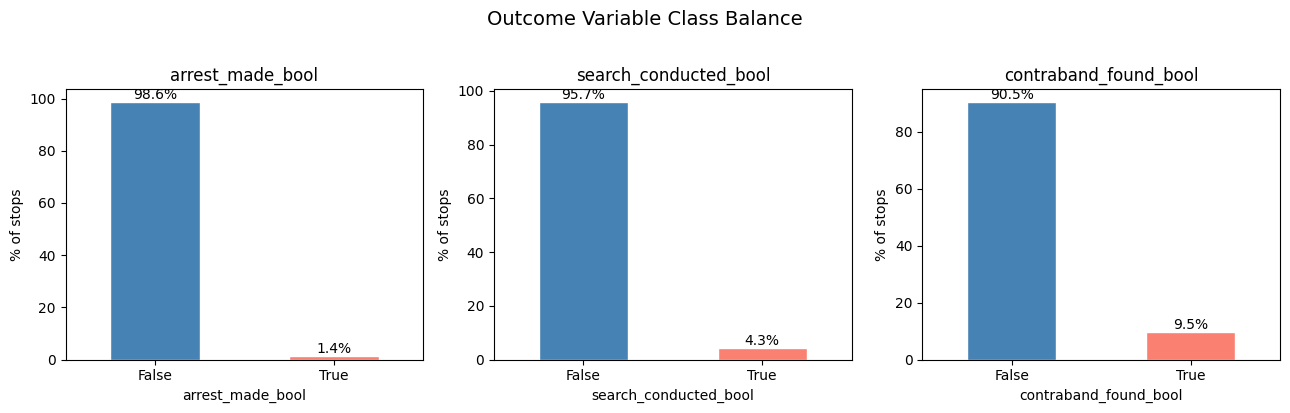

In [7]:
# search_conducted — clean bool, no NaNs
df["search_conducted_bool"] = df["search_conducted"].astype(bool)
print(f"search_conducted:  True={df['search_conducted_bool'].sum():,} "
      f"({df['search_conducted_bool'].mean():.3%})")

# arrest_made — stored as object ('True'/'False'/NaN)
df["arrest_made_bool"] = df["arrest_made"].map(
    lambda x: True  if str(x).lower() == "true"  else
             (False if str(x).lower() == "false" else None)
)
n = df["arrest_made_bool"].sum()
print(f"arrest_made:       True={int(n):,} "
      f"({n / df['arrest_made_bool'].notna().sum():.3%} of non-NaN)")

# contraband_found — meaningful only among searched stops
df["contraband_found_bool"] = df["contraband_found"].map(
    lambda x: True  if str(x).lower() == "true"  else
             (False if str(x).lower() == "false" else None)
)
searches = df[df["search_conducted_bool"]]
print(f"contraband_found:  True={searches['contraband_found_bool'].sum():,} "
      f"({searches['contraband_found_bool'].mean():.3%} of {len(searches):,} searches)")

outcomes = ['arrest_made_bool', 'search_conducted_bool', 'contraband_found_bool']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, outcomes):
    vc = df[col].value_counts(normalize=True) * 100
    vc.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('% of stops')
    ax.set_xticklabels(['False', 'True'], rotation=0)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
plt.suptitle('Outcome Variable Class Balance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.7 Demographic Distributions

=== SUBJECT RACE ===
subject_race
white                     162226
hispanic                  117083
black                      42705
asian/pacific islander     32541
other                      27238
NaN                         1234
Name: count, dtype: int64


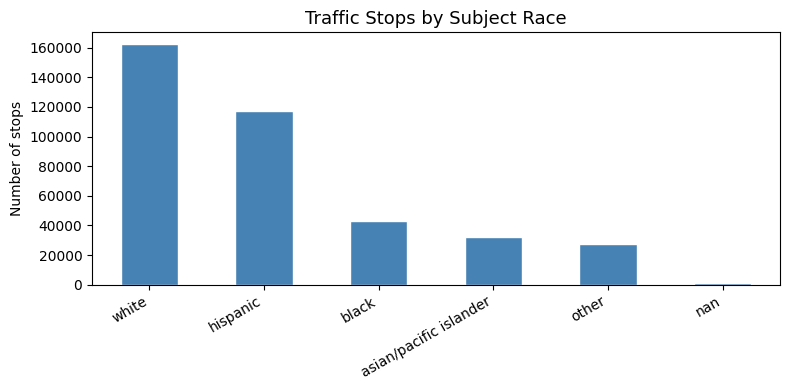

In [8]:
# race distribution
print("=== SUBJECT RACE ===")
print(df["subject_race"].value_counts(dropna=False))

race_counts = df_raw['subject_race'].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(8, 4))
race_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Traffic Stops by Subject Race', fontsize=13)
ax.set_ylabel('Number of stops')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_race_dist.png', dpi=150, bbox_inches='tight')
plt.show()


=== SUBJECT SEX ===
subject_sex
male      248398
female    133968
NaN          661
Name: count, dtype: int64


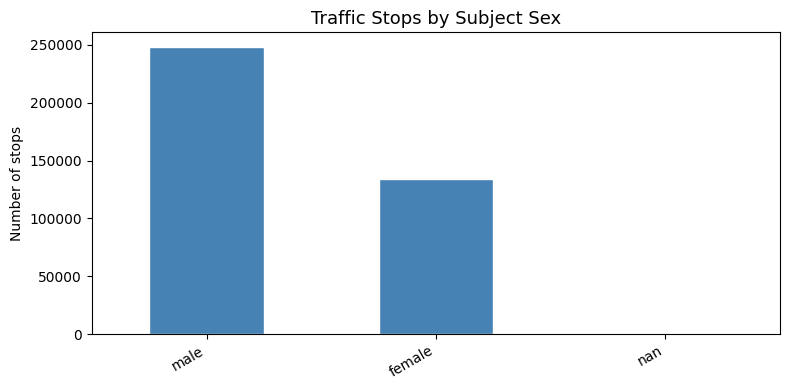

In [9]:
print("\n=== SUBJECT SEX ===")
print(df["subject_sex"].value_counts(dropna=False))

sex_counts = df_raw['subject_sex'].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(8, 4))
sex_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Traffic Stops by Subject Sex', fontsize=13)
ax.set_ylabel('Number of stops')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_sex_dist.png', dpi=150, bbox_inches='tight')
plt.show()


=== SUBJECT AGE ===
count    371064.000000
mean         37.095956
std          14.183295
min          10.000000
25%          25.000000
50%          34.000000
75%          47.000000
max         100.000000
Name: subject_age, dtype: float64


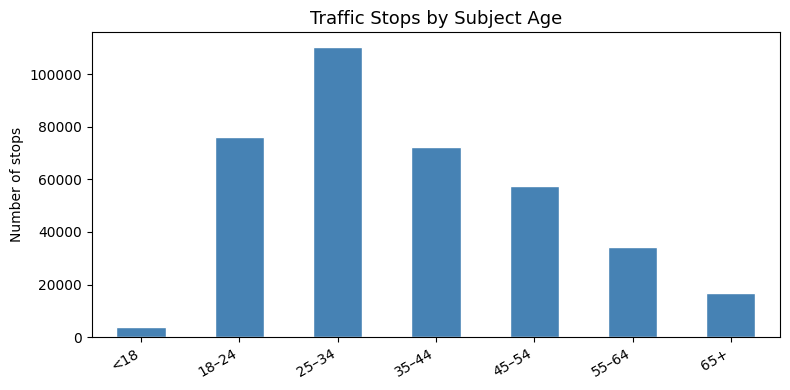

In [10]:
print("\n=== SUBJECT AGE ===")
print(df["subject_age"].describe())

# Define age range bins and labels
bins   = [0, 17, 24, 34, 44, 54, 64, 120]
labels = ['<18', '18–24', '25–34', '35–44', '45–54', '55–64', '65+']

# Cut continuous age into labelled buckets, then count
age_counts = pd.cut(df_raw['subject_age'], bins=bins, labels=labels).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
age_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Traffic Stops by Subject Age', fontsize=13)
ax.set_ylabel('Number of stops')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_age_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.8 Stop Reason Harmonisation

The raw `reason_for_stop` field has **98 distinct values** due to pipe-delimited multi-reason entries.  
We collapse these into 3 clean categories for modeling.

In [11]:
print(f"Unique raw values: {df['reason_for_stop'].nunique(dropna=False)}")
print("\nTop 10:")
print(df["reason_for_stop"].value_counts(dropna=False).head(10))

Unique raw values: 98

Top 10:
reason_for_stop
Moving Violation                        279839
Equipment Violation                      97372
Radio Call/Citizen Contact                1886
Muni, County, H&S Code                    1291
Personal Knowledge/Informant               860
Suspect Info (I.S., Bulletin, Log)         526
No Cause Specified on a Card               402
NaN                                        219
Personal Observ/Knowledge                  102
Equipment Violation|Moving Violation        96
Name: count, dtype: int64


stop_reason_clean
Moving Violation       280103
Equipment Violation     97389
Other                    5316
Unknown                   219
Name: count, dtype: int64


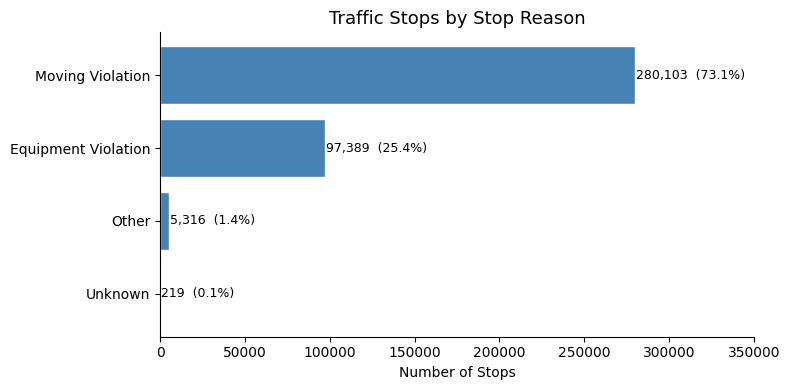

In [12]:
def clean_stop_reason(raw):
    """
    Collapse 98-value reason_for_stop into 3 modeling categories.
    Priority: Moving Violation → Equipment Violation → Other.
    """
    if pd.isna(raw):
        return "Unknown"
    raw = str(raw)
    if "Moving" in raw:
        return "Moving Violation"
    if "Equipment" in raw:
        return "Equipment Violation"
    return "Other"

df["stop_reason_clean"] = df["reason_for_stop"].map(clean_stop_reason)
print(df["stop_reason_clean"].value_counts())

stop_counts = df["stop_reason_clean"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(stop_counts.index, stop_counts.values, color='steelblue', edgecolor='white')

# Annotate each bar with count and percentage
total = stop_counts.sum()
for bar, val in zip(bars, stop_counts.values):
    ax.text(val + 500, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({val/total:.1%})', va='center', fontsize=9)

ax.set_title('Traffic Stops by Stop Reason', fontsize=13)
ax.set_xlabel('Number of Stops')
ax.set_xlim(0, stop_counts.max() * 1.25)  # extra room for labels
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_stop_reason.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.9 Descriptive Race × Outcome Cross-Tabs

This is **Table 2** in the paper — the raw disparity numbers before any modeling.

In [13]:
df["subject_race_clean"] = df["subject_race"].fillna("Unknown")

race_stats = df.groupby("subject_race_clean").agg(
    n_stops          = ("search_conducted_bool", "count"),
    n_searches       = ("search_conducted_bool", "sum"),
    n_arrests        = ("arrest_made_bool",      "sum"),   # NaN auto-excluded
    n_contraband     = ("contraband_found_bool",  "sum"),
).reset_index()

race_stats["pct_of_stops"]        = race_stats["n_stops"]    / race_stats["n_stops"].sum()
race_stats["search_rate"]         = race_stats["n_searches"]  / race_stats["n_stops"]
race_stats["arrest_rate"]         = race_stats["n_arrests"]   / race_stats["n_stops"]
race_stats["contraband_hit_rate"] = race_stats["n_contraband"]/ race_stats["n_searches"]

race_stats.sort_values("search_rate", ascending=False).style.format({
    "pct_of_stops": "{:.1%}", "search_rate": "{:.1%}",
    "arrest_rate": "{:.2%}", "contraband_hit_rate": "{:.1%}"
})

,subject_race_clean,n_stops,n_searches,n_arrests,n_contraband,pct_of_stops,search_rate,arrest_rate,contraband_hit_rate
2,black,42705,3873,857,361,11.1%,9.1%,2.01%,9.3%
3,hispanic,117083,6501,1714,528,30.6%,5.6%,1.46%,8.1%
0,Unknown,1234,43,4,8,0.3%,3.5%,0.32%,18.6%
1,asian/pacific islander,32541,910,309,95,8.5%,2.8%,0.95%,10.4%
5,white,162226,4510,1771,518,42.4%,2.8%,1.09%,11.5%
4,other,27238,451,160,43,7.1%,1.7%,0.59%,9.5%


### 1.10 Temporal Feature Engineering

In [14]:
# Extract numeric time features — these capture enforcement patterns by time-of-day/week
df["hour"]      = df["time_parsed"].dt.hour.fillna(12)   # impute missing as noon
df["month"]     = df["date"].dt.month                     # 1-12, seasonal variation
df["dayofweek"] = df["date"].dt.dayofweek                 # 0=Mon … 6=Sun
df["year"]      = df["date"].dt.year

# Night flag: 10pm–4am stops have higher search rates independent of race
df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 4)).astype(int)

print(f"Night-time stops: {df['is_night'].sum():,}  ({df['is_night'].mean():.2%})")

# Clean remaining categoricals (fill NaN → 'Unknown' so one-hot encoding works)
df["service_area_clean"] = df["service_area"].fillna("Unknown").astype(str)
for col in ["subject_race", "subject_sex", "stop_reason_clean", "service_area_clean"]:
    df[col] = df[col].fillna("Unknown")

Night-time stops: 78,279  (20.44%)


### 1.11 Build Model-Ready Feature Matrix

We include demographic features (`subject_race`, `subject_sex`) intentionally —  
they must be in the model so we can measure *how much* race predicts each outcome.

In [15]:
FEATURE_COLS = [
    "subject_age",        # continuous, mean-imputed
    "hour",               # engineered 0-23
    "month",              # engineered 1-12
    "dayofweek",          # engineered 0-6
    "is_night",           # engineered binary
    "subject_race",       # categorical → one-hot
    "subject_sex",        # categorical → one-hot
    "stop_reason_clean",  # harmonised categorical → one-hot
    "service_area_clean", # categorical → one-hot
]

# Drop rows with missing 'subject_age'; other missing handled by 'Unknown' encoding
df_model = df[FEATURE_COLS + [
    "search_conducted_bool", "arrest_made_bool",
    "contraband_found_bool", "date"
]].dropna(subset=["subject_age"])

print(f"Rows after age-drop: {len(df_model):,}  (removed {len(df)-len(df_model):,})")

# drop_first=False keeps ALL dummies so we can read individual race coefficients
X_all = pd.get_dummies(df_model[FEATURE_COLS], drop_first=False)
X_all["subject_age"] = X_all["subject_age"].fillna(X_all["subject_age"].median())

FEATURE_NAMES = list(X_all.columns)
print(f"Feature matrix: {X_all.shape[0]:,} rows × {X_all.shape[1]} columns")

Rows after age-drop: 371,064  (removed 11,963)
Feature matrix: 371,064 rows × 41 columns


### 1.12 Temporal Train / Test Split

> **Why temporal, not random?**  
> A random split lets the model see future data while training — e.g., learn from a November 2016 stop to predict a September 2016 stop. > Since policies and officer rosters shift over time, this inflates performance estimates.  
>
> **Split:** Train = Jan 2014 – Sep 2016 | Test = Oct 2016 – Mar 2017

In [16]:
CUTOFF = pd.Timestamp("2016-10-01")

train_mask = df_model["date"] < CUTOFF
test_mask  = df_model["date"] >= CUTOFF

X_train, X_test = X_all[train_mask], X_all[test_mask]

print(f"Train: {train_mask.sum():,} stops  "
      f"({df_model.loc[train_mask,'date'].min().date()} → "
      f"{df_model.loc[train_mask,'date'].max().date()})")
print(f"Test : {test_mask.sum():,} stops  "
      f"({df_model.loc[test_mask,'date'].min().date()} → "
      f"{df_model.loc[test_mask,'date'].max().date()})")

# RQ1 & RQ2 outcomes
y_train_rq1 = df_model.loc[train_mask, "arrest_made_bool"].fillna(0).astype(int)
y_test_rq1  = df_model.loc[test_mask,  "arrest_made_bool"].fillna(0).astype(int)
y_train_rq2 = df_model.loc[train_mask, "search_conducted_bool"].astype(int)
y_test_rq2  = df_model.loc[test_mask,  "search_conducted_bool"].astype(int)

# RQ3: restrict to searched stops only
search_mask  = df_model["search_conducted_bool"] == True
df_searches  = df_model[search_mask]
X_searches   = X_all[search_mask]
y_rq3        = df_searches["contraband_found_bool"].fillna(0).astype(int)

rq3_train = df_searches["date"] < CUTOFF
rq3_test  = df_searches["date"] >= CUTOFF

X_train_rq3, X_test_rq3 = X_searches[rq3_train], X_searches[rq3_test]
y_train_rq3, y_test_rq3 = y_rq3[rq3_train],      y_rq3[rq3_test]

print(f"\nRQ3 (searches only) — Train: {len(X_train_rq3):,} | Test: {len(X_test_rq3):,}")
print(f"  Contraband rate (train): {y_train_rq3.mean():.3%}")

Train: 320,369 stops  (2014-01-01 → 2016-09-30)
Test : 50,643 stops  (2016-10-01 → 2017-03-31)

RQ3 (searches only) — Train: 13,923 | Test: 2,262
  Contraband rate (train): 9.387%


In [17]:
# Save checkpoint so Parts 2 & 3 can load without re-running EDA
checkpoint = {
    "X_train": X_train, "X_test": X_test,
    "y_train_rq1": y_train_rq1, "y_test_rq1": y_test_rq1,
    "y_train_rq2": y_train_rq2, "y_test_rq2": y_test_rq2,
    "X_train_rq3": X_train_rq3, "X_test_rq3": X_test_rq3,
    "y_train_rq3": y_train_rq3, "y_test_rq3": y_test_rq3,
    "FEATURE_NAMES": FEATURE_NAMES,
    "race_stats": race_stats,
    "df_model": df_model,
}
with open("eda_checkpoint.pkl", "wb") as f:
    pickle.dump(checkpoint, f)
print("✓  eda_checkpoint.pkl saved")

✓  eda_checkpoint.pkl saved


---
## Part 2 — Model Training, Evaluation & Fairness Analysis


### 2.1 Imports & Load Checkpoint

In [18]:
import pickle, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import (roc_auc_score, f1_score,
                                   precision_score, recall_score,
                                   precision_recall_curve)

with open("eda_checkpoint.pkl", "rb") as f:
    ck = pickle.load(f)

X_train, X_test         = ck["X_train"],     ck["X_test"]
y_train_rq1, y_test_rq1 = ck["y_train_rq1"], ck["y_test_rq1"]
y_train_rq2, y_test_rq2 = ck["y_train_rq2"], ck["y_test_rq2"]
X_train_rq3, X_test_rq3 = ck["X_train_rq3"], ck["X_test_rq3"]
y_train_rq3, y_test_rq3 = ck["y_train_rq3"], ck["y_test_rq3"]
FEATURE_NAMES            = ck["FEATURE_NAMES"]

print(f"Train {X_train.shape[0]:,} × {X_train.shape[1]}  |  "
      f"Test {X_test.shape[0]:,}")

Train 320,369 × 41  |  Test 50,643


### 2.2 Evaluation Helper

In [19]:
def evaluate_model(y_true, y_pred_proba, label):
    """
    Returns AUC-ROC, F1, Precision, Recall at the threshold that maximises F1.

    We choose the F1-maximising threshold (not 0.5) because all outcomes are
    heavily imbalanced — a 0.5 threshold would almost never predict the
    minority class.  The chosen threshold is returned so stakeholders can
    understand the precision/recall trade-off.
    """
    auc = roc_auc_score(y_true, y_pred_proba)  # threshold-independent

    # precision_recall_curve returns n+1 values for prec/rec, n for thresholds
    prec_arr, rec_arr, thresholds = precision_recall_curve(y_true, y_pred_proba)
    f1_arr      = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
    best_thresh = thresholds[f1_arr.argmax()]

    y_pred = (y_pred_proba >= best_thresh).astype(int)
    f1  = f1_score(y_true,  y_pred, zero_division=0)
    pr  = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true,  y_pred, zero_division=0)

    print(f"  {label:38s}  AUC={auc:.4f}  F1={f1:.4f}  "
          f"Prec={pr:.4f}  Rec={rec:.4f}  thresh={best_thresh:.3f}")
    return {"auc": auc, "f1": f1, "precision": pr,
            "recall": rec, "threshold": best_thresh}

### 2.3 Training Loop — Logistic Regression & Random Forest

**Logistic Regression** is the primary model for the civil-rights audit:  
its coefficients are directly interpretable as log-odds / odds-ratios.

**Random Forest** is the predictive benchmark:  
it captures non-linear interactions and provides grouped feature importances.

In [20]:
tasks = [
    ("RQ1 – Arrest Made",      X_train,     y_train_rq1, X_test,     y_test_rq1),
    ("RQ2 – Search Conducted", X_train,     y_train_rq2, X_test,     y_test_rq2),
    ("RQ3 – Contraband Found", X_train_rq3, y_train_rq3, X_test_rq3, y_test_rq3),
]

all_results = {}

for task_label, Xtr, ytr, Xte, yte in tasks:
    print(f"\n{'─'*60}\nTask: {task_label}  (positive rate={ytr.mean():.3%})")
    res = {}

    # ── Logistic Regression ───────────────────────────────────────────────────
    # C=0.1 → moderate L2 regularisation for sparse one-hot features
    # class_weight='balanced' → compensates for severe class imbalance
    # solver='lbfgs' → efficient for medium-density dense problems
    lr = LogisticRegression(max_iter=500, C=0.1,
                             class_weight="balanced",
                             solver="lbfgs", random_state=42)
    lr.fit(Xtr, ytr)
    proba_lr   = lr.predict_proba(Xte)[:, 1]   # prob of class = 1
    metrics_lr = evaluate_model(yte, proba_lr, "Logistic Regression")
    res["lr"]  = {"model": lr, "proba": proba_lr, "metrics": metrics_lr}

    # ── Random Forest ─────────────────────────────────────────────────────────
    # max_depth=8 prevents overfitting on many sparse one-hot columns
    # n_jobs=-1 uses all CPU cores for parallel tree building
    rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                                 class_weight="balanced",
                                 random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    proba_rf   = rf.predict_proba(Xte)[:, 1]
    metrics_rf = evaluate_model(yte, proba_rf, "Random Forest")
    res["rf"]  = {"model": rf, "proba": proba_rf, "metrics": metrics_rf}

    res["y_test"] = yte
    all_results[task_label] = res


────────────────────────────────────────────────────────────
Task: RQ1 – Arrest Made  (positive rate=1.313%)
  Logistic Regression                     AUC=0.7782  F1=0.0993  Prec=0.0800  Rec=0.1310  thresh=0.823
  Random Forest                           AUC=0.7881  F1=0.1048  Prec=0.0757  Rec=0.1701  thresh=0.693

────────────────────────────────────────────────────────────
Task: RQ2 – Search Conducted  (positive rate=4.346%)
  Logistic Regression                     AUC=0.7752  F1=0.2134  Prec=0.1530  Rec=0.3523  thresh=0.733
  Random Forest                           AUC=0.7691  F1=0.2142  Prec=0.1433  Rec=0.4240  thresh=0.640

────────────────────────────────────────────────────────────
Task: RQ3 – Contraband Found  (positive rate=9.387%)
  Logistic Regression                     AUC=0.5969  F1=0.2183  Prec=0.1253  Rec=0.8475  thresh=0.423
  Random Forest                           AUC=0.6050  F1=0.2244  Prec=0.1339  Rec=0.6907  thresh=0.436


### 2.4 Logistic Regression Race Coefficients (RQ2 Focus)

In [21]:
lr_rq2 = all_results["RQ2 – Search Conducted"]["lr"]["model"]

# All feature coefficients as a DataFrame
coef_df = pd.DataFrame({
    "feature":    FEATURE_NAMES,
    "log_odds":   lr_rq2.coef_[0]
})
# Exponentiate → odds ratios (OR=2 means "twice the odds of being searched")
coef_df["odds_ratio"] = np.exp(coef_df["log_odds"])

# Isolate race coefficients (one-hot produced e.g. subject_race_black)
race_coefs = coef_df[coef_df["feature"].str.startswith("subject_race_")].copy()
race_coefs = race_coefs.sort_values("log_odds", ascending=False)
print("Race coefficients (sorted high→low):"); print(race_coefs.to_string(index=False))

Race coefficients (sorted high→low):
                            feature  log_odds  odds_ratio
                 subject_race_black  0.818054    2.266086
              subject_race_hispanic  0.548483    1.730626
                 subject_race_white  0.119757    1.127223
subject_race_asian/pacific islander -0.050900    0.950373
                 subject_race_other -0.452967    0.635739
               subject_race_Unknown -0.722901    0.485342


In [22]:
# Re-express vs. white as reference — more intuitive for a policy audience
white_coef = coef_df.loc[coef_df["feature"]=="subject_race_white","log_odds"].values[0]
print(f"White coefficient: {white_coef:.4f}\n")
print(f"{'Group':30s}  Δ log-odds  OR vs White")
print("─"*55)
for _, row in race_coefs.iterrows():
    group = row["feature"].replace("subject_race_","")
    delta = row["log_odds"] - white_coef
    OR    = np.exp(delta)
    print(f"  {group:28s}  {delta:+.4f}      {OR:.4f}")

White coefficient: 0.1198

Group                           Δ log-odds  OR vs White
───────────────────────────────────────────────────────
  black                         +0.6983      2.0103
  hispanic                      +0.4287      1.5353
  white                         +0.0000      1.0000
  asian/pacific islander        -0.1707      0.8431
  other                         -0.5727      0.5640
  Unknown                       -0.8427      0.4306


In [23]:
# Top 20 features by absolute magnitude — context for the race coefficients
top20 = coef_df.reindex(coef_df["log_odds"].abs().sort_values(ascending=False).index).head(20)
print("Top 20 features by |coefficient| (RQ2 – Search):")
print(top20[["feature","log_odds","odds_ratio"]].to_string(index=False))

Top 20 features by |coefficient| (RQ2 – Search):
                           feature  log_odds  odds_ratio
           stop_reason_clean_Other  1.473894    4.366206
                subject_race_black  0.818054    2.266086
stop_reason_clean_Moving Violation -0.737255    0.478426
            service_area_clean_710 -0.724069    0.484776
              subject_race_Unknown -0.722901    0.485342
            service_area_clean_830  0.716420    2.047092
            service_area_clean_440  0.686109    1.985973
            service_area_clean_510  0.675561    1.965135
            service_area_clean_930 -0.597809    0.550016
         stop_reason_clean_Unknown -0.592237    0.553088
            service_area_clean_820  0.589704    1.803455
            service_area_clean_430  0.582164    1.789908
             subject_race_hispanic  0.548483    1.730626
            service_area_clean_230 -0.520064    0.594483
            service_area_clean_530  0.493812    1.638550
                          is_night  0.4

### 2.5 Random Forest Grouped Feature Importance (RQ2)

In [24]:
rf_rq2 = all_results["RQ2 – Search Conducted"]["rf"]["model"]

fi_df = pd.DataFrame({
    "feature":    FEATURE_NAMES,
    "importance": rf_rq2.feature_importances_
})

def group_feature(fname):
    """Sum per-dummy importances back into their conceptual variable group."""
    if fname.startswith("subject_race"):                      return "Subject Race"
    if fname.startswith("subject_sex"):                       return "Subject Sex"
    if fname.startswith("stop_reason"):                       return "Stop Reason"
    if fname.startswith("service_area"):                      return "Service Area"
    if fname in ["hour","is_night","month","dayofweek"]:      return "Time Features"
    if fname == "subject_age":                                return "Subject Age"
    return "Other"

fi_df["group"] = fi_df["feature"].map(group_feature)
grouped_importance = (fi_df.groupby("group")["importance"]
                        .sum().sort_values(ascending=False).reset_index())
grouped_importance["importance_pct"] = grouped_importance["importance"] * 100

print(grouped_importance.to_string(index=False))
race_pct = grouped_importance.loc[grouped_importance["group"]=="Subject Race","importance_pct"].values[0]
print(f"\n→ Subject Race: {race_pct:.1f}% of total importance — 2nd behind Stop Reason")

        group  importance  importance_pct
  Stop Reason    0.395073       39.507252
 Subject Race    0.182833       18.283340
 Service Area    0.125482       12.548189
  Subject Sex    0.120117       12.011710
Time Features    0.115681       11.568074
  Subject Age    0.060814        6.081436

→ Subject Race: 18.3% of total importance — 2nd behind Stop Reason


### 2.6 Hit-Rate Benchmarking (Outcome-Based Fairness Test)

The **contraband hit rate** is the most legally robust fairness test:  
- It conditions only on *completed searches* (not who was stopped)  
- If officers apply the same evidentiary threshold regardless of race, hit rates should be equal  
- A lower hit rate = lower evidentiary bar applied = disparate enforcement threshold

In [25]:
race_stats = ck["race_stats"]
white_hit  = race_stats.loc[race_stats["subject_race_clean"]=="white",
                             "contraband_hit_rate"].values[0]

print(f"White motorist hit rate (reference): {white_hit:.4f}\n")
print(f"{'Group':30s}  hit_rate  gap_vs_white  interpretation")
print("─"*72)
for _, row in race_stats.sort_values("contraband_hit_rate").iterrows():
    gap  = row["contraband_hit_rate"] - white_hit
    flag = "← LOWER evidentiary threshold" if gap < -0.01 else ""
    print(f"  {row['subject_race_clean']:28s}  {row['contraband_hit_rate']:.4f}    "
          f"{gap:+.4f}        {flag}")

White motorist hit rate (reference): 0.1149

Group                           hit_rate  gap_vs_white  interpretation
────────────────────────────────────────────────────────────────────────
  hispanic                      0.0812    -0.0336        ← LOWER evidentiary threshold
  black                         0.0932    -0.0216        ← LOWER evidentiary threshold
  other                         0.0953    -0.0195        ← LOWER evidentiary threshold
  asian/pacific islander        0.1044    -0.0105        ← LOWER evidentiary threshold
  white                         0.1149    +0.0000        
  Unknown                       0.1860    +0.0712        


In [26]:
# Save everything for Part 3
modeling_output = {
    "all_results":        all_results,
    "coef_df":            coef_df,
    "white_coef":         white_coef,
    "grouped_importance": grouped_importance,
    "race_stats":         race_stats,
    "FEATURE_NAMES":      FEATURE_NAMES,
}
with open("modeling_results.pkl", "wb") as f:
    pickle.dump(modeling_output, f)
print("✓  modeling_results.pkl saved")

✓  modeling_results.pkl saved


---
## Part 3 — Visualisations


### 3.1 Imports & Load Results

In [27]:
with open("modeling_results.pkl", "rb") as f:
    mo = pickle.load(f)

all_results       = mo["all_results"]
coef_df           = mo["coef_df"]
white_coef        = mo["white_coef"]
grouped_imp       = mo["grouped_importance"]
race_stats        = mo["race_stats"]

# Unpack per-race numbers into flat lists (sorted by search rate, high→low)
rs = race_stats.sort_values("search_rate", ascending=False)
RACE_LABELS  = rs["subject_race_clean"].str.title().tolist()
SEARCH_RATES = (rs["search_rate"] * 100).tolist()
HIT_RATES    = (rs["contraband_hit_rate"] * 100).tolist()
ARREST_RATES = (rs["arrest_rate"] * 100).tolist()
PCT_STOPS    = rs["pct_of_stops"].tolist()

# Odds ratios vs. white from logistic regression (re-derived here for self-containment)
rc = coef_df[coef_df["feature"].str.startswith("subject_race_")].copy()
rc["group"]      = rc["feature"].str.replace("subject_race_","",regex=False).str.title()
rc["or_vs_white"]= np.exp(rc["log_odds"] - white_coef)
OR_df = rc[rc["group"] != "White"].sort_values("or_vs_white", ascending=False)

GROUPS      = grouped_imp["group"].tolist()
IMPORTANCES = (grouped_imp["importance"] * 100).tolist()

def get_auc(task, model):
    return all_results[task][model]["metrics"]["auc"]

LR_AUCS = [get_auc("RQ1 – Arrest Made","lr"),
           get_auc("RQ2 – Search Conducted","lr"),
           get_auc("RQ3 – Contraband Found","lr")]
RF_AUCS = [get_auc("RQ1 – Arrest Made","rf"),
           get_auc("RQ2 – Search Conducted","rf"),
           get_auc("RQ3 – Contraband Found","rf")]
print("Data loaded successfully")

Data loaded successfully


### 3.2 Colour Palette & Style Helper

In [28]:
# Consistent colour palette across all charts
NAVY   = "#1a2e4a"   # headings, navy bars
ACCENT = "#2563eb"   # primary blue bars / highlighted elements
RED    = "#dc2626"   # disparity highlight (above-avg search rate)
GREEN  = "#16a34a"   # good outcome / below reference
AMBER  = "#d97706"   # intermediate
GRAY   = "#6b7280"   # secondary text, reference lines
LGRAY  = "#f0f4ff"   # panel background

def style_ax(ax, title, xlabel=None, ylabel=None):
    """Remove clutter, set background, apply consistent title/label styling."""
    ax.set_facecolor(LGRAY)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_title(title, fontsize=10.5, fontweight="bold", color=NAVY, pad=8)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9, color=GRAY)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9, color=GRAY)
    ax.tick_params(labelsize=8.5)

### 3.3 Figure 1 — 6-Panel Results Dashboard

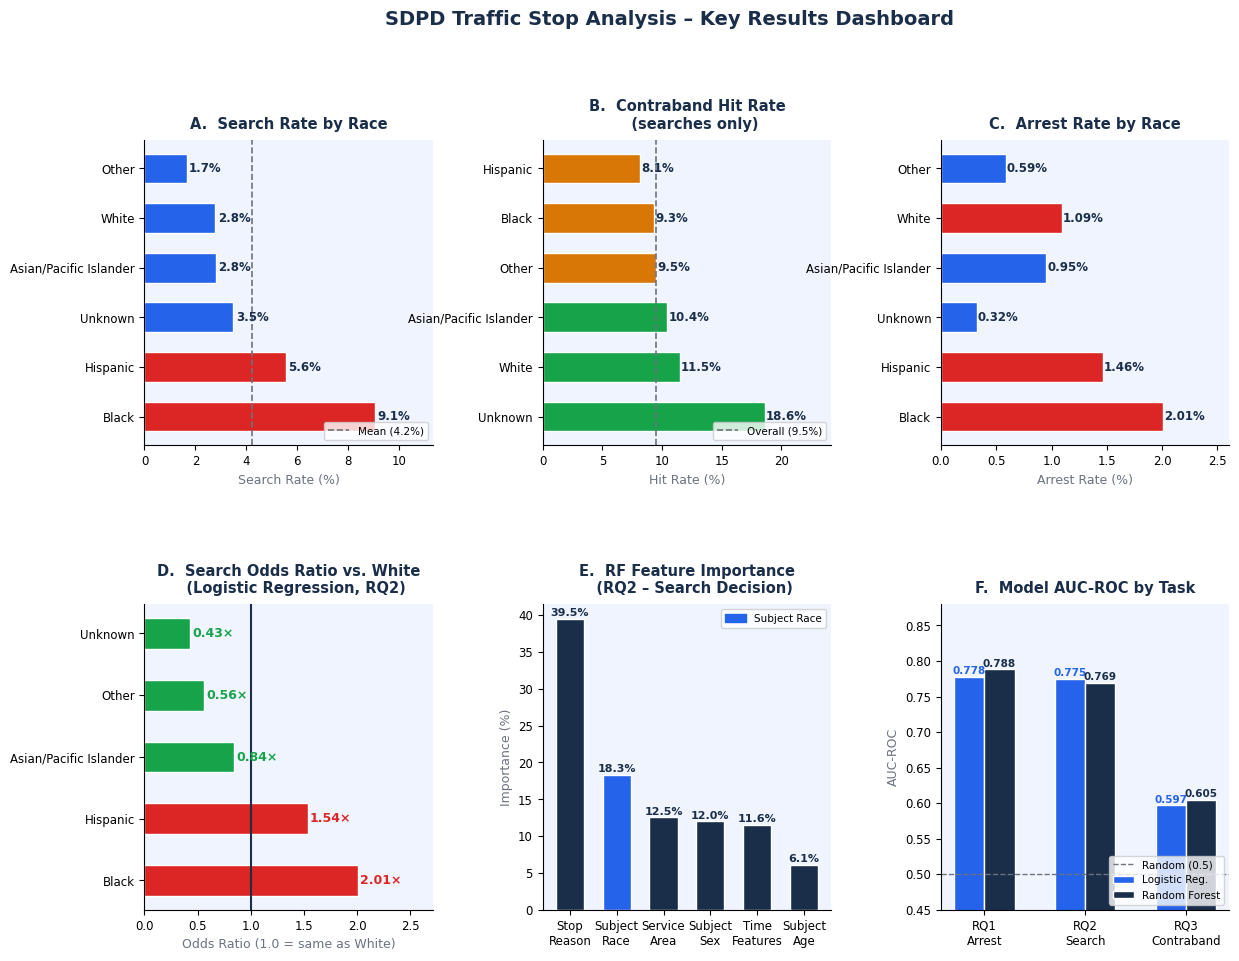

✓  fig_dashboard.png saved


In [29]:
fig = plt.figure(figsize=(14,10))
fig.patch.set_facecolor("white")
gs  = GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.38)

# ── Panel A: Search Rate by Race ──────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0,0])
avg_search = np.mean(SEARCH_RATES)
# Red = above average (disparity signal), blue = below average
bc_a = [RED if r > avg_search else ACCENT for r in SEARCH_RATES]
bars = ax_a.barh(RACE_LABELS, SEARCH_RATES, color=bc_a, edgecolor="white", height=0.6)
ax_a.axvline(avg_search, color=GRAY, lw=1.2, ls="--", label=f"Mean ({avg_search:.1f}%)")
for bar, v in zip(bars, SEARCH_RATES):
    ax_a.text(v+0.1, bar.get_y()+bar.get_height()/2,
              f"{v:.1f}%", va="center", fontsize=8.5, color=NAVY, fontweight="bold")
style_ax(ax_a, "A.  Search Rate by Race", xlabel="Search Rate (%)")
ax_a.set_xlim(0, max(SEARCH_RATES)*1.25); ax_a.legend(fontsize=7.5, loc="lower right")

# ── Panel B: Contraband Hit Rate by Race ─────────────────────────────────────
ax_b = fig.add_subplot(gs[0,1])
hit_order = sorted(zip(RACE_LABELS, HIT_RATES), key=lambda x: x[1], reverse=True)
h_labels, h_vals = zip(*hit_order)
overall_hit = 9.535  # actual overall contraband rate
# Green = above overall rate (more accurate searches), amber = below
bc_b  = [GREEN if v >= overall_hit else AMBER for v in h_vals]
bars2 = ax_b.barh(h_labels, h_vals, color=bc_b, edgecolor="white", height=0.6)
ax_b.axvline(overall_hit, color=GRAY, lw=1.2, ls="--", label=f"Overall ({overall_hit:.1f}%)")
for bar, v in zip(bars2, h_vals):
    ax_b.text(v+0.1, bar.get_y()+bar.get_height()/2,
              f"{v:.1f}%", va="center", fontsize=8.5, color=NAVY, fontweight="bold")
style_ax(ax_b, "B.  Contraband Hit Rate\n   (searches only)", xlabel="Hit Rate (%)")
ax_b.set_xlim(0, max(h_vals)*1.3); ax_b.legend(fontsize=7.5, loc="lower right")

# ── Panel C: Arrest Rate by Race ──────────────────────────────────────────────
ax_c = fig.add_subplot(gs[0,2])
avg_arr = np.mean(ARREST_RATES)
bc_c  = [RED if r > avg_arr else ACCENT for r in ARREST_RATES]
bars3 = ax_c.barh(RACE_LABELS, ARREST_RATES, color=bc_c, edgecolor="white", height=0.6)
for bar, v in zip(bars3, ARREST_RATES):
    ax_c.text(v+0.01, bar.get_y()+bar.get_height()/2,
              f"{v:.2f}%", va="center", fontsize=8.5, color=NAVY, fontweight="bold")
style_ax(ax_c, "C.  Arrest Rate by Race", xlabel="Arrest Rate (%)")
ax_c.set_xlim(0, max(ARREST_RATES)*1.3)

# ── Panel D: Odds Ratios vs. White ───────────────────────────────────────────
ax_d = fig.add_subplot(gs[1,0])
or_labels = OR_df["group"].tolist()
or_vals   = OR_df["or_vs_white"].tolist()
bc_d  = [RED if v > 1 else GREEN for v in or_vals]  # red = higher odds than white
bars4 = ax_d.barh(or_labels, or_vals, color=bc_d, edgecolor="white", height=0.5)
ax_d.axvline(1.0, color=NAVY, lw=1.5)               # OR=1 reference line
for bar, v in zip(bars4, or_vals):
    ax_d.text(v+0.02, bar.get_y()+bar.get_height()/2,
              f"{v:.2f}×", va="center", fontsize=9, fontweight="bold",
              color=RED if v > 1 else GREEN)
style_ax(ax_d, "D.  Search Odds Ratio vs. White\n   (Logistic Regression, RQ2)",
         xlabel="Odds Ratio (1.0 = same as White)")
ax_d.set_xlim(0, max(or_vals)*1.2+0.3)

# ── Panel E: RF Grouped Feature Importance ────────────────────────────────────
ax_e = fig.add_subplot(gs[1,1])
fc_e  = [ACCENT if g=="Subject Race" else NAVY for g in GROUPS]
bars5 = ax_e.bar(GROUPS, IMPORTANCES, color=fc_e, edgecolor="white", width=0.6)
for bar, v in zip(bars5, IMPORTANCES):
    ax_e.text(bar.get_x()+bar.get_width()/2, v+0.4,
              f"{v:.1f}%", ha="center", fontsize=8, fontweight="bold", color=NAVY)
ax_e.set_xticklabels([g.replace(" ","\n") if " " in g else g for g in GROUPS], fontsize=8)
style_ax(ax_e, "E.  RF Feature Importance\n   (RQ2 – Search Decision)", ylabel="Importance (%)")
ax_e.legend(handles=[mpatches.Patch(color=ACCENT, label="Subject Race")],
            fontsize=7.5, loc="upper right")

# ── Panel F: AUC-ROC by Task ──────────────────────────────────────────────────
ax_f = fig.add_subplot(gs[1,2])
task_labels = ["RQ1\nArrest","RQ2\nSearch","RQ3\nContraband"]
x, bw = np.arange(3), 0.3
ax_f.bar(x-bw/2, LR_AUCS, bw, label="Logistic Reg.", color=ACCENT, edgecolor="white")
ax_f.bar(x+bw/2, RF_AUCS, bw, label="Random Forest", color=NAVY,   edgecolor="white")
ax_f.axhline(0.5, color=GRAY, lw=1, ls="--", label="Random (0.5)")
for i,(lv,rv) in enumerate(zip(LR_AUCS,RF_AUCS)):
    ax_f.text(i-bw/2, lv+0.004, f"{lv:.3f}", ha="center", fontsize=7.5, color=ACCENT, fontweight="bold")
    ax_f.text(i+bw/2, rv+0.004, f"{rv:.3f}", ha="center", fontsize=7.5, color=NAVY,   fontweight="bold")
ax_f.set_xticks(x); ax_f.set_xticklabels(task_labels, fontsize=8.5)
ax_f.set_ylim(0.45, 0.88)
style_ax(ax_f, "F.  Model AUC-ROC by Task", ylabel="AUC-ROC")
ax_f.legend(fontsize=7.5, loc="lower right")

fig.suptitle("SDPD Traffic Stop Analysis – Key Results Dashboard",
             fontsize=14, fontweight="bold", color=NAVY, y=1.01)
plt.savefig("fig_dashboard.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
print("✓  fig_dashboard.png saved")

### 3.4 Figure 2 — Search Rate vs. Hit Rate Bubble Chart

This chart illustrates the **central disparity**:  
groups in the **lower-right** (high search rate, low hit rate) face the most lenient  
evidentiary threshold — evidence of disparate enforcement.

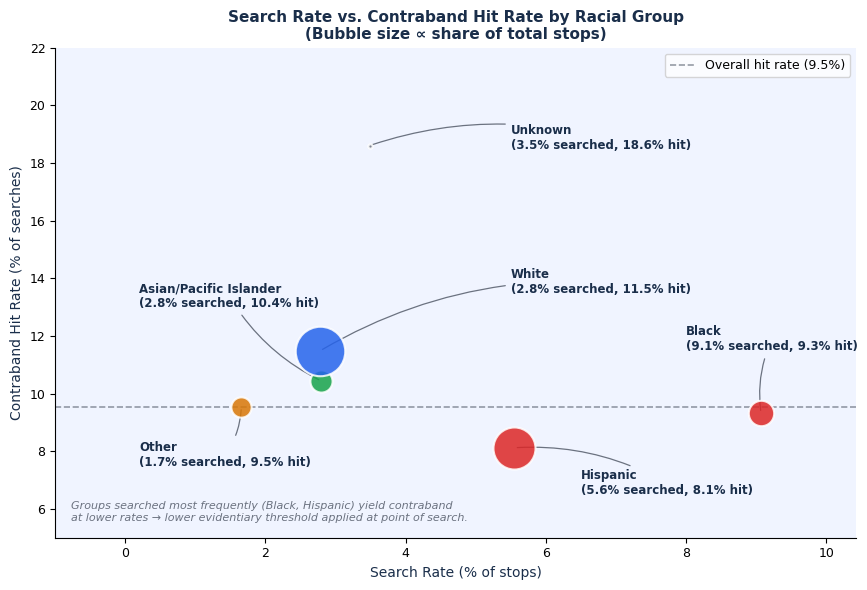

✓  fig_scatter.png saved


In [30]:
fig2, ax2 = plt.subplots(figsize=(9, 6))  # slightly wider for label room
fig2.patch.set_facecolor("white")
ax2.set_facecolor(LGRAY)

bubble_colors = {
    "White": ACCENT, "Hispanic": RED, "Black": RED,
    "Asian/Pacific Islander": GREEN, "Other": AMBER, "Unknown": GRAY
}

# Anchor labels well away from the crowded 2.5–3.0 x-range
# Format: (text_x, text_y) in data coordinates
label_positions = {
    "White":                   (5.5, 13.5),
    "Hispanic":                (6.5,  6.5),
    "Black":                   (8.0, 11.5),
    "Asian/Pacific Islander":  (0.2, 13.0),
    "Other":                   (0.2,  7.5),
    "Unknown":                 (5.5, 18.5),
}

race_display = race_stats.copy()
race_display["label"] = race_display["subject_race_clean"].str.title()

for _, row in race_display.iterrows():
    lbl  = row["label"]
    sr   = row["search_rate"] * 100
    hr   = row["contraband_hit_rate"] * 100
    size = row["pct_of_stops"] * 3000
    col  = bubble_colors.get(lbl, AMBER)

    ax2.scatter(sr, hr, s=size, color=col,
                edgecolors="white", linewidths=1.5, zorder=5, alpha=0.85)

    tx, ty = label_positions.get(lbl, (sr + 0.2, hr + 0.3))
    ax2.annotate(
        f"{lbl}\n({sr:.1f}% searched, {hr:.1f}% hit)",
        xy=(sr, hr),           # arrow points to bubble centre
        xytext=(tx, ty),       # label sits at the fixed anchor
        fontsize=8.5, color=NAVY, fontweight="bold",
        ha="left",
        arrowprops=dict(
            arrowstyle="-",
            color=GRAY,
            lw=0.9,
            connectionstyle="arc3,rad=0.15",  # gentle curve avoids crossing lines
        )
    )

ax2.axhline(overall_hit, color=GRAY, lw=1.2, ls="--",
            alpha=0.7, label=f"Overall hit rate ({overall_hit:.1f}%)")
ax2.set_xlabel("Search Rate (% of stops)", fontsize=10, color=NAVY)
ax2.set_ylabel("Contraband Hit Rate (% of searches)", fontsize=10, color=NAVY)
ax2.set_title("Search Rate vs. Contraband Hit Rate by Racial Group\n"
              "(Bubble size ∝ share of total stops)",
              fontsize=11, fontweight="bold", color=NAVY)
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.tick_params(labelsize=9)
ax2.set_xlim(-1, max(SEARCH_RATES) * 1.15)
ax2.set_ylim(5, 22)  # expanded top to make room for Unknown and White labels
ax2.text(0.02, 0.03,
         "Groups searched most frequently (Black, Hispanic) yield contraband\n"
         "at lower rates → lower evidentiary threshold applied at point of search.",
         transform=ax2.transAxes, fontsize=8, color=GRAY, style="italic", va="bottom")

plt.tight_layout()
plt.savefig("fig_scatter.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
print("✓  fig_scatter.png saved")

### 3.5 Final Metrics Summary Table

In [31]:
rows = []
for task_label, short in [("RQ1 – Arrest Made","RQ1"),
                            ("RQ2 – Search Conducted","RQ2"),
                            ("RQ3 – Contraband Found","RQ3")]:
    for mk, mn in [("lr","Logistic Regression"),("rf","Random Forest")]:
        m = all_results[task_label][mk]["metrics"]
        rows.append({"Task":short, "Model":mn,
                     "AUC-ROC":m["auc"],"F1":m["f1"],
                     "Precision":m["precision"],"Recall":m["recall"],
                     "Threshold":m["threshold"]})

summary_df = pd.DataFrame(rows)
summary_df.style.format({
    "AUC-ROC":"{:.4f}","F1":"{:.4f}",
    "Precision":"{:.4f}","Recall":"{:.4f}","Threshold":"{:.3f}"
}).set_caption("Table 3 — Model Performance on Temporal Holdout Test Set")

,Task,Model,AUC-ROC,F1,Precision,Recall,Threshold
0,RQ1,Logistic Regression,0.7782,0.0993,0.0800,0.1310,0.823
1,RQ1,Random Forest,0.7881,0.1048,0.0757,0.1701,0.693
2,RQ2,Logistic Regression,0.7752,0.2134,0.1530,0.3523,0.733
3,RQ2,Random Forest,0.7691,0.2142,0.1433,0.4240,0.640
4,RQ3,Logistic Regression,0.5969,0.2183,0.1253,0.8475,0.423
5,RQ3,Random Forest,0.6050,0.2244,0.1339,0.6907,0.436
